In [1]:
import time
import os
import random
import numpy as np                                                
import matplotlib.pyplot as plt                                   
import autograd, autograd.core, autograd.extend, autograd.tracer  
import autograd.numpy as anp      
import scipy, scipy.ndimage, scipy.sparse, scipy.sparse.linalg    
                                                     
import gym
# from gym import spaces
from gymnasium import spaces


from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.results_plotter import load_results, ts2xy
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common import results_plotter
from scipy.signal import convolve2d

from skfem import *
from skfem.models.elasticity import eye, sym_grad
from skfem.helpers import dot, ddot, trace

In [2]:
# the purpose of this experiment is to investigate if there is a checkerboard problem

In [3]:
x0, y0 = 12, 12

In [4]:
def FEA_u(x0, y0, el, load=10):
   
    # --------------------------------------------------
    # 1. Mesh (2D Quad)
    # --------------------------------------------------
    x = np.linspace(0, 1, x0)
    y = np.linspace(0, 1, y0)
    m = MeshQuad.init_tensor(x, y).with_defaults()

    e = ElementVector(ElementQuad1())
    basis = Basis(m, e, intorder=3)

    # --------------------------------------------------
    # 2. Spatially varying elastic modulus
    # --------------------------------------------------
    num_nodes = m.p.shape[1]
    # Ensure el matches the node count
    E_nodal = np.array(el)

    basis_s = basis.with_element(ElementQuad1())
    E_param = basis_s.interpolate(E_nodal)

    # --------------------------------------------------
    # 3. Material law (Plane Stress)
    # --------------------------------------------------
    nu = 0.3

    @BilinearForm
    def stiffness(u, v, w):
        E = w['elastic_modulus']
        # Plane Stress constants
        lam = E * nu / (1. - nu**2)
        mu = E / (2. * (1. + nu))

        def C(T):
            # 2D Plane Stress Constitutive Law
            return 2. * mu * T + lam * eye(trace(T), 2)

        return ddot(C(sym_grad(u)), sym_grad(v))

    K = stiffness.assemble(basis, elastic_modulus=E_param)

    # --------------------------------------------------
    # 4. Load (Lower Right Corner, Downward)
    # --------------------------------------------------
    f = basis.zeros()
    coords = m.p.T
    tol = 1e-8
    
    # Identify Lower Right: x is max, y is min (0)
    lr_node = np.where(
        (np.abs(coords[:, 0] - 1.0) < tol) &
        (np.abs(coords[:, 1] - 0.0) < tol)
    )[0]

    # Apply downward force (-y direction) to the y-DOF
    # basis.nodal_dofs[1, ...] corresponds to the y-component
    y_dof_lr = basis.nodal_dofs[1, lr_node]
    f[y_dof_lr] -= load

    # --------------------------------------------------
    # 5. Fix Upper Left and Lower Left Corners
    # --------------------------------------------------
    # Upper Left (x=0, y=1) and Lower Left (x=0, y=0)
    fixed_nodes = np.where(
        (np.abs(coords[:, 0] - 0.0) < tol) & 
        ((np.abs(coords[:, 1] - 1.0) < tol) | (np.abs(coords[:, 1] - 0.0) < tol))
    )[0]

    # Fix both x and y displacements (all DOFs for these nodes)
    fixed_dofs = basis.nodal_dofs[:, fixed_nodes].ravel()

    # --------------------------------------------------
    # 6. Solve
    # --------------------------------------------------
    u = solve(*condense(K, f, D=fixed_dofs))

    compliance = f @ u

    return u, compliance

In [5]:
def get_stiffness(volume):
    el = np.where(volume == 1, 1e3, 1e-4)
    return el.ravel(order='F') 

In [6]:
class Model:
    def __init__(self, x):
        self.flag_ = True
        self.n, self.m = x.shape
        self.actions_dic={} 
    
        k=0
        for i in range(self.n):
            for j in range(self.m):
                self.actions_dic[k]=(i,j)
                k+=1
        
    def action_space_(self, action, X):
        x,y=self.actions_dic[action]
        X[x][y]=1
        
    def draw(self,X):  
        plt.figure(dpi=50) 
        print('\nFinal Cantilever beam design:')
        plt.imshow(X) 
        plt.show()

In [7]:
def fast_stopt(args, x):

    reshape = lambda x: x.reshape(args.nely, args.nelx)
    objective_fn = lambda x: objective(reshape(x), args)
#     constraint = lambda params: mean_density(reshape(params), args) - args.density
    constraint = lambda params: mean_density(reshape(params), args) 
    value = objective_fn(x)
    const = constraint(x)
    return value, const

In [8]:
def calculate_smoothness_metric(binary_matrix):
    """
    Calculates a smoothness metric for a 2D binary matrix.
    Lower values indicate greater smoothness. A value of 0 means 
    the image is perfectly uniform or has only linear transitions.

    The metric is the sum of differences between a pixel and its
    right and bottom neighbors, effectively counting vertical and
    horizontal edges.

    Args:
        binary_matrix (list of lists or numpy array): A 2D matrix 
                                                     with values 0 or 1.

    Returns:
        int: The total count of horizontal and vertical transitions.
    """
    # Convert to a numpy array for efficient processing
    matrix = np.array(binary_matrix, dtype=int)
    h, w = matrix.shape
    
    # Calculate absolute differences for horizontal transitions
    # We slice the matrix to compare each element with its right neighbor
    horizontal_diffs = np.abs(matrix[:, :w-1] - matrix[:, 1:])
    
    # Calculate absolute differences for vertical transitions
    # We slice the matrix to compare each element with its bottom neighbor
    vertical_diffs = np.abs(matrix[:h-1, :] - matrix[1:, :])
    
    # The sum of these differences gives the total number of transitions (edges)
    total_transitions = np.sum(horizontal_diffs) + np.sum(vertical_diffs)
    
    return int(total_transitions)

In [9]:
def count_islands_dfs(grid):
    """
    Calculates the number of islands in a 2D binary grid using Depth First Search (DFS).

    An island is formed by connected 1's (horizontally/vertically adjacent).
    
    Args:
        grid (list of lists): A 2D matrix with values 0 or 1.

    Returns:
        int: The total number of islands found.
    """
#     if not grid or not grid[0]:
#         return 0
    
    rows = len(grid)
    cols = len(grid[0])
    visited = set()
    island_count = 0

    def dfs(r, c):
        """Helper function to traverse and mark a single island as visited."""
        # Check boundary conditions and if the cell has already been visited or is water (0)
        if r < 0 or r >= rows or c < 0 or c >= cols or grid[r][c] == 0 or (r, c) in visited:
            return
        
        visited.add((r, c))
        
        # Recursively visit all adjacent cells (up, down, left, right)
        dfs(r + 1, c) # Down
        dfs(r - 1, c) # Up
        dfs(r, c + 1) # Right
        dfs(r, c - 1) # Left

    # Iterate through every cell in the grid
    for r in range(rows):
        for c in range(cols):
            # If we find land (1) that hasn't been visited yet, 
            # it means we've found the start of a new island.
            if grid[r][c] == 1 and (r, c) not in visited:
                island_count += 1
                # Start DFS from this point to mark all parts of this island
                dfs(r, c)
                
    return island_count

In [10]:
class CantileverEnv(gym.Env):
    
    metadata = {"render.modes": ["human"]}

    def __init__(self):
        super().__init__()
        
        
        self.rd=0
      
        
        DIM=x0*y0
        N_DISCRETE_ACTIONS=x0*y0
        
        self.action_space = spaces.Discrete(N_DISCRETE_ACTIONS)
        self.observation_space = spaces.Box(low=np.array([-1e10 for x in range(DIM)]),
                                            high=np.array([1e10 for y in range(DIM)]),
                                            shape=(DIM,),
                                           dtype=np.float64)
        
 
        self.x = anp.ones((x0, y0))**1e-04
    
        self.M=Model(self.x)
        
        self.reward=0
        self.step_=0
        self.needs_reset = True
        
    def step(self, action):
        
    
        
        self.M.action_space_(action, self.x)
        
        
        self.step_+=1
        
        
        done=False
        
        s_u = np.sum(self.x)
       
        if bool(s_u > 0.7*x0*y0):
            done = True
                 
        if self.step_ > x0 * y0 :
            done=True 
               
        if done:
            el=get_stiffness(self.x)
            d, compliance  = FEA_u(x0,y0,el)
            self.reward = 1/compliance + 1/calculate_smoothness_metric(self.x.reshape(y0,x0))
            if count_islands_dfs(self.x)==1:
                self.reward*=100
        else:
            self.reward = 0
            
        if self.needs_reset:
            raise RuntimeError("Tried to step environment that needs reset")
            
        if done:
            self.needs_reset = True
                         
      
        return self.x.reshape(self.x.shape[0]*self.x.shape[1]), self.reward, done,False, dict()

    def reset(self,seed=0):
        
        if not self.M.flag_:
            self.rd=random.choice([0,2,-2])
        else:
            self.rd=-1
           
        self.x = anp.ones((x0, y0))*1e-04 

        self.reward=0
        self.needs_reset = False
        self.step_=0

        return self.x.reshape(self.x.shape[0]*self.x.shape[1]),{}

    def render(self, mode="human"):
        self.M.draw(self.x)    

    def close(self):
        pass

In [11]:
class SaveOnBestTrainingRewardCallback(BaseCallback):
    """
    Callback for saving a model (the check is done every ``check_freq`` steps)
    based on the training reward (in practice, we recommend using ``EvalCallback``).

    :param check_freq: (int)
    :param log_dir: (str) Path to the folder where the model will be saved.
      It must contains the file created by the ``Monitor`` wrapper.
    :param verbose: (int)
    """

    def __init__(self, check_freq: int, log_dir: str, verbose=1):
        super().__init__(verbose)
        self.check_freq = check_freq
        self.log_dir = log_dir
        self.save_path = os.path.join(log_dir, "best_model")
        self.best_mean_reward = -np.inf

    def _init_callback(self) -> None:
        # Create folder if needed
        if self.save_path is not None:
            os.makedirs(self.save_path, exist_ok=True)

    def _on_step(self) -> bool:
        if self.n_calls % self.check_freq == 0:

            # Retrieve training reward
            x, y = ts2xy(load_results(self.log_dir), "timesteps")
            if len(x) > 0:
                # Mean training reward over the last 100 episodes
                mean_reward = np.mean(y[-100:])
                if self.verbose > 0:
                    print(f"Num timesteps: {self.num_timesteps}")
                    print(
                        f"Best mean reward: {self.best_mean_reward:.2f} - Last mean reward per episode: {mean_reward:.2f}"
                    )

                # New best model, you could save the agent here
                if mean_reward > self.best_mean_reward:
                    self.best_mean_reward = mean_reward
                    # Example for saving best model
                    if self.verbose > 0:
                        print(f"Saving new best model to {self.save_path}.zip")
                    self.model.save(self.save_path)

        return True

In [12]:
# ts=5e6
ts=4e6

In [13]:
# Create log dir
log_dir = "/tmp/gym6_2bmuuj/"
os.makedirs(log_dir, exist_ok=True)

# Create and wrap the environment
env = CantileverEnv()
# Logs will be saved in log_dir/monitor.csv
env = Monitor(env, log_dir)
check_env(env)

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.render_mode to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.render_mode` for environment variables or `env.get_wrapper_attr('render_mode')` that will search the reminding wrappers.
  logger.warn(
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/stable_baselines3/common/vec_env/base_vec_env.py:77: UserWarning: The `render_mode` attribute is not defined in your environment. It will be set to None.
  warnings.warn("The `render_mode` attribute is not defined in your environment. It will be set to None.")


In [14]:
# callback = SaveOnBestTrainingRewardCallback(check_freq=5000, log_dir=log_dir)
callback = SaveOnBestTrainingRewardCallback(check_freq=100_000, log_dir=log_dir)

In [15]:
start=time.time()
model = PPO("MlpPolicy", env).learn(total_timesteps=ts, callback=callback)
end=time.time()   

Num timesteps: 100000
Best mean reward: -inf - Last mean reward per episode: 33.69
Saving new best model to /tmp/gym6_2bmuuj/best_model.zip
Num timesteps: 200000
Best mean reward: 33.69 - Last mean reward per episode: 36.68
Saving new best model to /tmp/gym6_2bmuuj/best_model.zip
Num timesteps: 300000
Best mean reward: 36.68 - Last mean reward per episode: 35.74
Num timesteps: 400000
Best mean reward: 36.68 - Last mean reward per episode: 37.05
Saving new best model to /tmp/gym6_2bmuuj/best_model.zip
Num timesteps: 500000
Best mean reward: 37.05 - Last mean reward per episode: 37.51
Saving new best model to /tmp/gym6_2bmuuj/best_model.zip
Num timesteps: 600000
Best mean reward: 37.51 - Last mean reward per episode: 38.39
Saving new best model to /tmp/gym6_2bmuuj/best_model.zip
Num timesteps: 700000
Best mean reward: 38.39 - Last mean reward per episode: 37.91
Num timesteps: 800000
Best mean reward: 38.39 - Last mean reward per episode: 42.13
Saving new best model to /tmp/gym6_2bmuuj/be

In [16]:
print('Total time taken: {} min'.format((end - start)/60))

Total time taken: 31.582604547341663 min


### Inference

In [17]:
def prune_binary_matrix(mat):
    """
    Remove (set to 0) all elements in a 2D binary matrix that have < 2 neighbors.
    Neighbors include 8 directions (Moore neighborhood). Boundaries handled naturally.
    """
    # 3x3 kernel of ones minus center → counts neighbors only
    kernel = np.array([[1,1,1],
                       [1,0,1],
                       [1,1,1]])

    # Count neighbors using convolution
    neighbor_count = convolve2d(mat, kernel, mode='same', boundary='fill', fillvalue=0)

    # Keep elements that have at least 2 neighbors
    pruned = np.where(neighbor_count >=2, mat, 0)

    return pruned

In [18]:
env.M.flag_=True
# env.M.flag_=False
obs=env.reset()
obs=obs[0]

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.M to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.M` for environment variables or `env.get_wrapper_attr('M')` that will search the reminding wrappers.
  logger.warn(


In [19]:
i=0
while i<1000:
    action, _states = model.predict(obs)
    obs, rewards, dones, _, info = env.step(int(action))
    if dones:
        break
    i+=1

In [20]:
obs=obs.reshape(y0,x0)

In [21]:
for i in range(obs.shape[0]):
    for j in range(obs.shape[1]):
        if obs[i][j]==1e-04:
            obs[i][j]=0
        else:
            obs[i][j]=1

In [22]:
obs=prune_binary_matrix(obs)

In [23]:
top=(obs.reshape(x0,y0)== 1).astype(int)


Final Cantilever beam design:


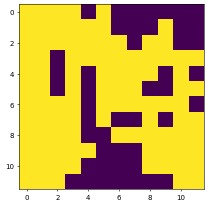

In [24]:
env.M.draw(np.rot90(top))

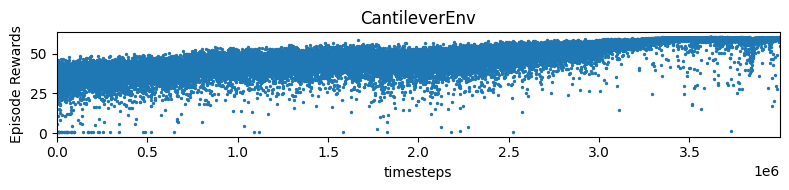

In [25]:
results_plotter.plot_results([log_dir], ts, results_plotter.X_TIMESTEPS, "CantileverEnv")

In [26]:
env.M.flag_=False
obs=env.reset()
obs=obs[0]

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.M to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.M` for environment variables or `env.get_wrapper_attr('M')` that will search the reminding wrappers.
  logger.warn(


In [27]:
# Load the agent
model_best = PPO.load(log_dir + "best_model.zip",env=env)

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.render_mode to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.render_mode` for environment variables or `env.get_wrapper_attr('render_mode')` that will search the reminding wrappers.
  logger.warn(
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/stable_baselines3/common/vec_env/base_vec_env.py:77: UserWarning: The `render_mode` attribute is not defined in your environment. It will be set to None.
  warnings.warn("The `render_mode` attribute is not defined in your environment. It will be set to None.")


In [28]:
i=0
while i<1000:
    action, _states = model_best.predict(obs)
    
    obs, rewards, dones, _,info = env.step(int(action))
    if dones:
        break
    i+=1

In [29]:
obs=obs.reshape(y0,x0)

In [30]:
for i in range(obs.shape[0]):
    for j in range(obs.shape[1]):
        if obs[i][j]==1e-04:
            obs[i][j]=0
        else:
            obs[i][j]=1

In [31]:
obs=prune_binary_matrix(obs)

In [32]:
top=(obs.reshape(x0,y0)== 1).astype(int)


Final Cantilever beam design:


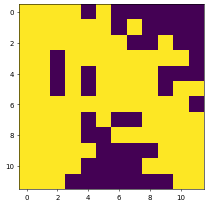

In [33]:
env.M.draw(np.rot90(top))